# Датасет **House Prices - Advanced Regression Techniques**. 
*Хороший датасет для тренировки Feature Engineering и проведения EDA.*

https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data

In [208]:
# импорт библиотек
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [209]:
# игнорируем бесячие предупреждения
import warnings
warnings.filterwarnings('ignore')

In [210]:
# извлекаем датасеи из .csv и настраиваем отображение
df = pd.read_csv('data/train.csv')
pd.set_option('display.max_rows', None) #отображение всех строк
pd.set_option('display.max_columns', None) #отображение всех столбцов


## A) Быстрый обзор данных (Pandas)

df.head(), df.tail(), df.shape.

In [211]:
print("Df.shape: ",df.shape)
display(df.head())
display(df.tail())

Df.shape:  (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1999,2000,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,Unf,0,Unf,0,953,953,GasA,Ex,Y,SBrkr,953,694,0,1647,0,0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1999.0,RFn,2,460,TA,TA,Y,0,40,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,6,1978,1988,Gable,CompShg,Plywood,Plywood,Stone,119.0,TA,TA,CBlock,Gd,TA,No,ALQ,790,Rec,163,589,1542,GasA,TA,Y,SBrkr,2073,0,0,2073,1,0,2,0,3,1,TA,7,Min1,2,TA,Attchd,1978.0,Unf,2,500,TA,TA,Y,349,0,0,0,0,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,9,1941,2006,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,Ex,Gd,Stone,TA,Gd,No,GLQ,275,Unf,0,877,1152,GasA,Ex,Y,SBrkr,1188,1152,0,2340,0,0,2,0,4,1,Gd,9,Typ,2,Gd,Attchd,1941.0,RFn,1,252,TA,TA,Y,0,60,0,0,0,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1950,1996,Hip,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,TA,TA,Mn,GLQ,49,Rec,1029,0,1078,GasA,Gd,Y,FuseA,1078,0,0,1078,1,0,1,0,2,1,Gd,5,Typ,0,NaN,Attchd,1950.0,Unf,1,240,TA,TA,Y,366,0,112,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Norm,Norm,1Fam,1Story,5,6,1965,1965,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,Gd,TA,CBlock,TA,TA,No,BLQ,830,LwQ,290,136,1256,GasA,Gd,Y,SBrkr,1256,0,0,1256,1,0,1,1,3,1,TA,6,Typ,0,NaN,Attchd,1965.0,Fin,1,276,TA,TA,Y,736,68,0,0,0,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


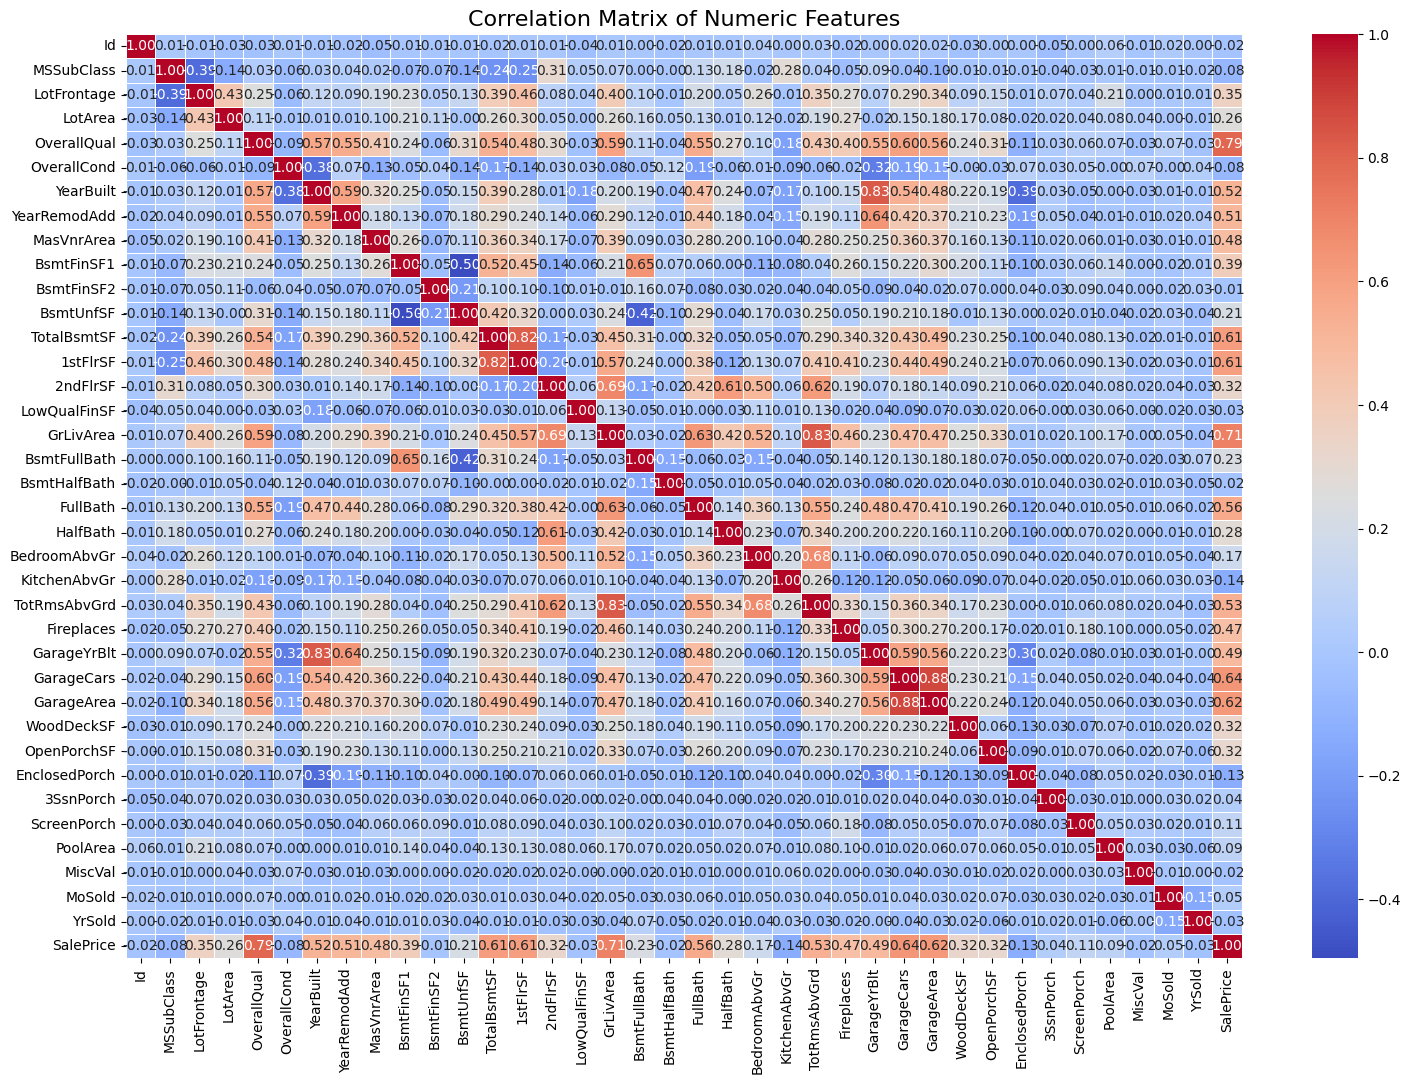

In [212]:
# Построим матрицу корреляции для числовых столбцов
plt.figure(figsize=(18, 12))
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features', fontsize=16)
plt.show()

df.info() и df.describe() (отдельно .describe(include="object") для строк)

In [213]:
df.info()
display(df.describe()) # анализ: числовые значения
display(df.describe(include="object")) # анализ только строковых значений
                                        # include="all" для всего

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Heating,HeatingQC,CentralAir,Electrical,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
count,1460,1460,91,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,588,1460,1460,1460,1423,1423,1422,1423,1422,1460,1460,1460,1459,1460,1460,770,1379,1379,1379,1379,1460,7,281,54,1460,1460
unique,5,2,2,4,4,2,5,3,25,9,8,5,8,6,8,15,16,3,4,5,6,4,4,4,6,6,6,5,2,5,4,7,5,6,3,5,5,3,3,4,4,9,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,TA,TA,PConc,TA,TA,No,Unf,Unf,GasA,Ex,Y,SBrkr,TA,Typ,Gd,Attchd,Unf,TA,TA,Y,Gd,MnPrv,Shed,WD,Normal
freq,1151,1454,50,925,1311,1459,1052,1382,225,1260,1445,1220,726,1141,1434,515,504,445,906,1282,647,649,1311,953,430,1256,1428,741,1365,1334,735,1360,380,870,605,1311,1326,1340,3,157,49,1267,1198


Проверка качества №1: isnull().sum() + графики


Missing Values: 
 Id                  0
MSSubClass          0
MSZoning            0
LotFrontage       259
LotArea             0
Street              0
Alley            1369
LotShape            0
LandContour         0
Utilities           0
LotConfig           0
LandSlope           0
Neighborhood        0
Condition1          0
Condition2          0
BldgType            0
HouseStyle          0
OverallQual         0
OverallCond         0
YearBuilt           0
YearRemodAdd        0
RoofStyle           0
RoofMatl            0
Exterior1st         0
Exterior2nd         0
MasVnrType        872
MasVnrArea          8
ExterQual           0
ExterCond           0
Foundation          0
BsmtQual           37
BsmtCond           37
BsmtExposure       38
BsmtFinType1       37
BsmtFinSF1          0
BsmtFinType2       38
BsmtFinSF2          0
BsmtUnfSF           0
TotalBsmtSF         0
Heating             0
HeatingQC           0
CentralAir          0
Electrical          1
1stFlrSF            0
2ndFlrSF     

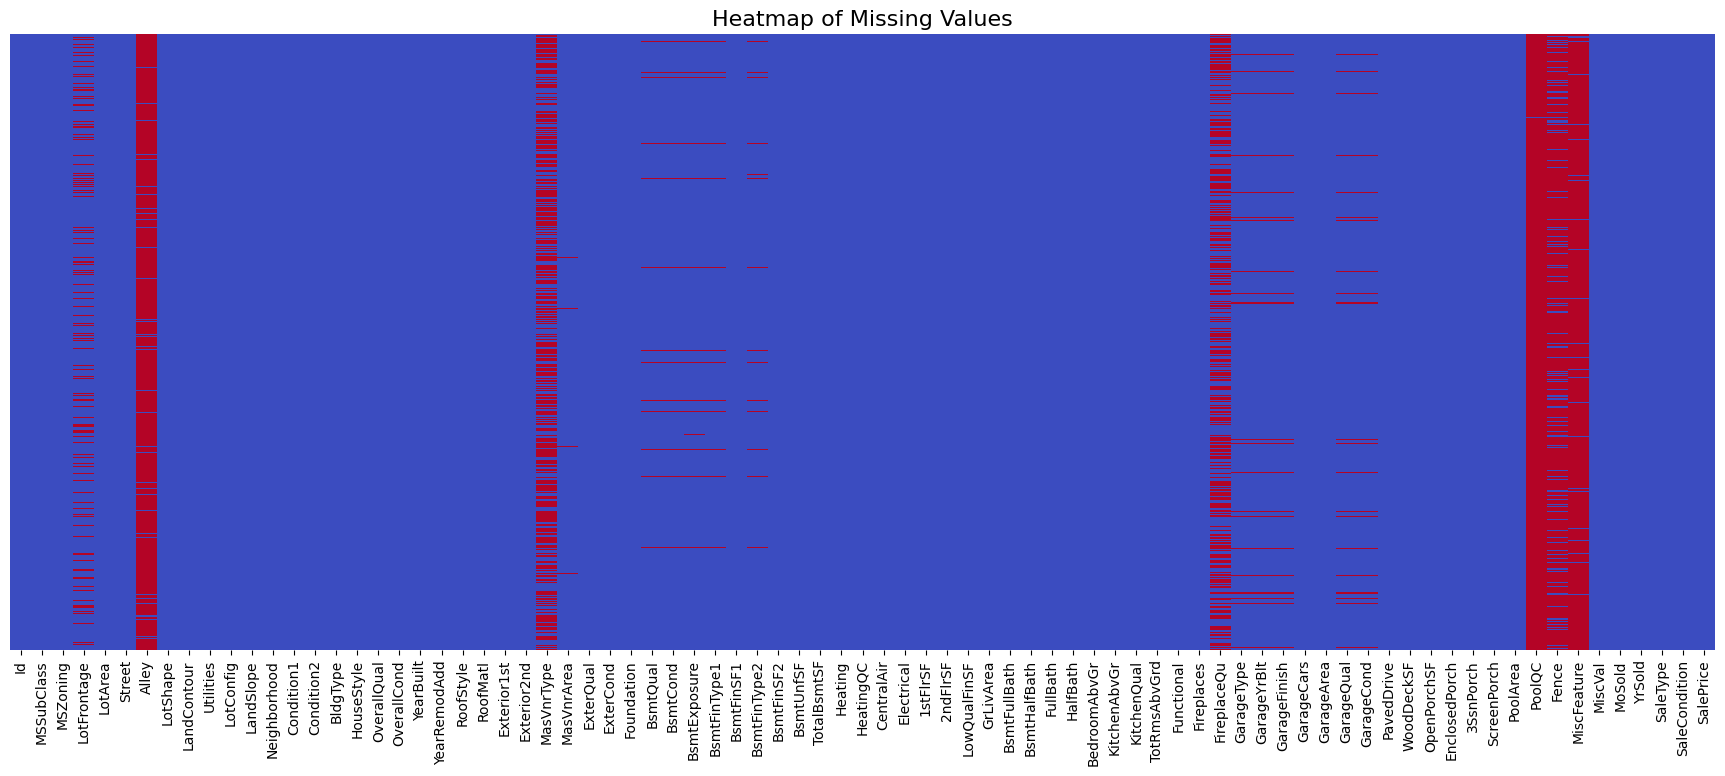

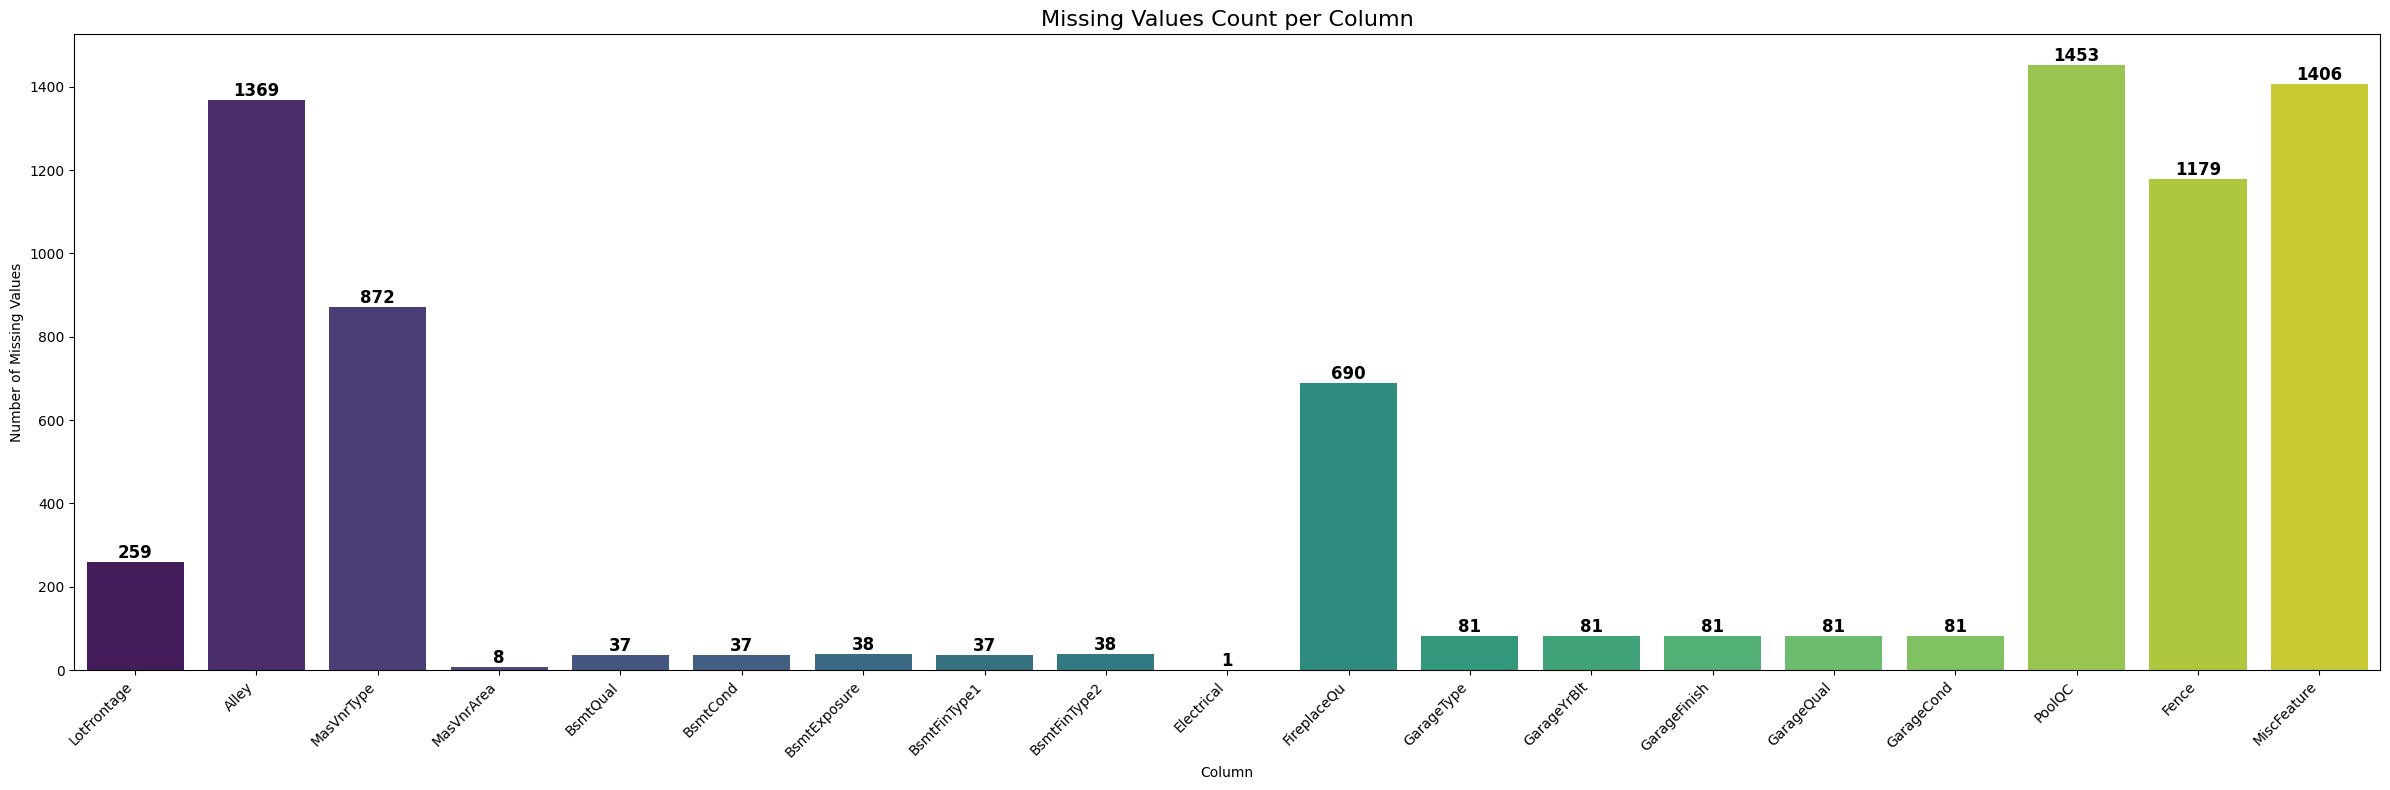

In [214]:
# проверка на пропущенные значения
missing_counts = df.isnull().sum()
print("\nMissing Values: \n",missing_counts)
print("\nPercent of Missing Values: \n",missing_counts/len(df)*100,"%")
print("\nColumns with Missing Values: \n", missing_counts[missing_counts > 0])

# наглядное представление пропусков значений - тепловая карта
plt.figure(figsize=(22, 8))
sns.heatmap(df.isnull(), cbar=False, cmap='coolwarm', yticklabels=False)
plt.title('Heatmap of Missing Values', fontsize=16)
plt.show()

# наглядное представление только пропущенных значений - столбчатая диаграмма
cols_with_missing = missing_counts[missing_counts > 0]

plt.figure(figsize=(24, 8))
ax = sns.barplot(x=cols_with_missing.index, y=cols_with_missing.values, palette='viridis')
plt.title('Missing Values Count per Column', fontsize=16)
plt.ylabel('Number of Missing Values')
plt.xlabel('Column')

# добавление значения количества пропущенных значений на каждую колонку
for i, count in enumerate(cols_with_missing.values):
    ax.text(i, count, str(count), ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



Вывод: большое количество пропущенных данных, особенно в катгориальных колонках

Проверка качества №2: поиск дубликатов

In [215]:
print(f"Number of Duplicates: {df.duplicated().sum()}")

Number of Duplicates: 0


Вывод: дупликатов нет

Проверка качества №3: проверка адекватности типов данных

In [216]:
# print("\n Data Types for each Column:", df.dtypes) # проверка типов данных

# Проверка уникальных значений по категориальным колонкам + проверка типов данных 
# (полезно для поиска неожиданных или ошибочных категорий)
cat_columns = df.select_dtypes(include='object').columns
for col in cat_columns:
    print(f"\nColumn: {col}")
    print(df[col].value_counts(dropna=False))

# Проверка на неадекватные значения, например отрицательные площади или возраста
print("\n" + "-"*55)
if 'LotArea' in df.columns:
    print("Наличие отрицательных или нулевых LotArea:", (df['LotArea'] <= 0).sum())
if 'YearBuilt' in df.columns:
    print("Минимальный год постройки:", df['YearBuilt'].min())
if 'TotalBsmtSF' in df.columns:
    print("Наличие отрицательных или нулевых TotalBsmtSF:", (df['TotalBsmtSF'] <= 0).sum())
if 'GrLivArea' in df.columns:
    print("Наличие отрицательных или нулевых GrLivArea:", (df['GrLivArea'] <= 0).sum())
if 'BedroomAbvGr' in df.columns:
    print("Наличие отрицательных BedroomAbvGr:", (df['BedroomAbvGr'] < 0).sum())
if 'FullBath' in df.columns:
    print("Наличие отрицательных FullBath:", (df['FullBath'] < 0).sum())
if 'GarageCars' in df.columns:
    print("Наличие отрицательных GarageCars:", (df['GarageCars'] < 0).sum())
if 'GarageArea' in df.columns:
    print("Наличие отрицательных GarageArea:", (df['GarageArea'] < 0).sum())
if 'SalePrice' in df.columns:
    print("Наличие отрицательных или нулевых SalePrice:", (df['SalePrice'] <= 0).sum())

# Можно проверить частоту редких значений в категориальных признаках
print("\n" + "-"*55)
for col in cat_columns:
    rare = df[col].value_counts(normalize=True)
    print(f"Редкие категории в {col}:")
    print(rare[rare < 0.01])
    print("-" * 40)



Column: MSZoning
MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64

Column: Street
Street
Pave    1454
Grvl       6
Name: count, dtype: int64

Column: Alley
Alley
NaN     1369
Grvl      50
Pave      41
Name: count, dtype: int64

Column: LotShape
LotShape
Reg    925
IR1    484
IR2     41
IR3     10
Name: count, dtype: int64

Column: LandContour
LandContour
Lvl    1311
Bnk      63
HLS      50
Low      36
Name: count, dtype: int64

Column: Utilities
Utilities
AllPub    1459
NoSeWa       1
Name: count, dtype: int64

Column: LotConfig
LotConfig
Inside     1052
Corner      263
CulDSac      94
FR2          47
FR3           4
Name: count, dtype: int64

Column: LandSlope
LandSlope
Gtl    1382
Mod      65
Sev      13
Name: count, dtype: int64

Column: Neighborhood
Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSid

Вывод: данные адекватны

## B) Пропуски и очистка

Покажите стратегии dropna() и fillna(). Заполняйте средним, медианой, константой — и обязательно обоснуйте выбор текстовым комментарием.

In [217]:
# 1. Удаление строк с пропусками (dropna)
# Эта стратегия подходит, если доля пропусков в данных очень мала, и их удаление не влияет на анализ.
df_dropna = df.dropna()
print("Удалили все строки с хотя бы одним пропуском.")
print(f"Размер данных после dropna: {df_dropna.shape}")
display(df_dropna.head())

Удалили все строки с хотя бы одним пропуском.
Размер данных после dropna: (0, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice


Вывод: нет строк без пропусков, поэтому этот метод отсеивания данных не подходит.

Попробуем заполнить пропуски разными значениями. Категориальные в осноном будем заполнять значением 'No*' или модой, числовые же медианами (или 0, если это имеет смысл).

Например, значения LotFrontage заполняем медианами ПО ГРУППАМ LotConfig, так как само наличие LotConfig показывает, что LotFrontage не должен быть пустой. Чтобы не допустить выбросов, будем находить медиану именно по значениям LotConfig, а не медиану всех имеющихся значений LotFrontage.

In [218]:
# Заполнение пропущенных значений LotFrontage медианой внутри каждой группы LotConfig
df_corrected = df.copy()
df_corrected['LotFrontage'] = df.groupby('LotConfig')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

# Alley и MasVnrType: замена пропусков на "NoAlley" и "NoVrn"
df_corrected['Alley'] = df_corrected['Alley'].fillna('NoAlley')  # нет аллеи
df_corrected['MasVnrType'] = df_corrected['MasVnrType'].fillna('NoVrn')  # нет облицовки

# MasVnrArea: пропуски заменить на 0 (нет площади облицовки)
df_corrected['MasVnrArea'] = df_corrected['MasVnrArea'].fillna(0)

# BsmtQual, BsmtCond, BsmtExposure, BsmtFinType1, BsmtFinType2: пропуски заменить на "NoBasement"
for col in ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']:
    df_corrected[col] = df_corrected[col].fillna('NoBasement')  # нет подвала

# Electrical: заполнить пропуски модой по колонке (самое частое значение электропроводки)
electrical_mode = df_corrected['Electrical'].mode(dropna=True)[0]
df_corrected['Electrical'] = df_corrected['Electrical'].fillna(electrical_mode)

# FireplaceQu:
# Если в Fireplaces==0, пропуск FireplaceQu -> "None", иначе (если встретится) заполняем модой
# (обычно FireplaceQu пустая только если печей нет)
fireplacequ_mode = df_corrected['FireplaceQu'].mode(dropna=True)[0]
def fill_fireplacequ(row):
    if pd.isna(row['FireplaceQu']):
        return "None" if row['Fireplaces'] == 0 else fireplacequ_mode
    else:
        return row['FireplaceQu']

df_corrected['FireplaceQu'] = df_corrected.apply(fill_fireplacequ, axis=1)

# GarageType, GarageFinish, GarageQual, GarageCond: заполнить "NoGarage"
for col in ['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']:
    df_corrected[col] = df_corrected[col].fillna('NoGarage')

# GarageYrBlt: заполнять пропуски оставляем np.nan (это уже NaN, ничего не делаем, комментарий)
# Пропуски GarageYrBlt оставлены как np.nan (отмечено по заданию)

# Fence: заполнить "NoFence"
df_corrected['Fence'] = df_corrected['Fence'].fillna('NoFence')

# MiscFeature: заполнить "NoFeature"
df_corrected['MiscFeature'] = df_corrected['MiscFeature'].fillna('NoFeature')


df_corrected['PoolQC'] = df_corrected['PoolQC'].fillna('NoPool')


display(df_corrected.head())


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NoAlley,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,None,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NoPool,NoFence,NoFeature,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NoAlley,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NoVrn,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NoPool,NoFence,NoFeature,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NoAlley,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NoPool,NoFence,NoFeature,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NoAlley,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NoVrn,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NoPool,NoFence,NoFeature,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NoAlley,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NoPool,NoFence,NoFeature,0,12,2008,WD,Normal,250000


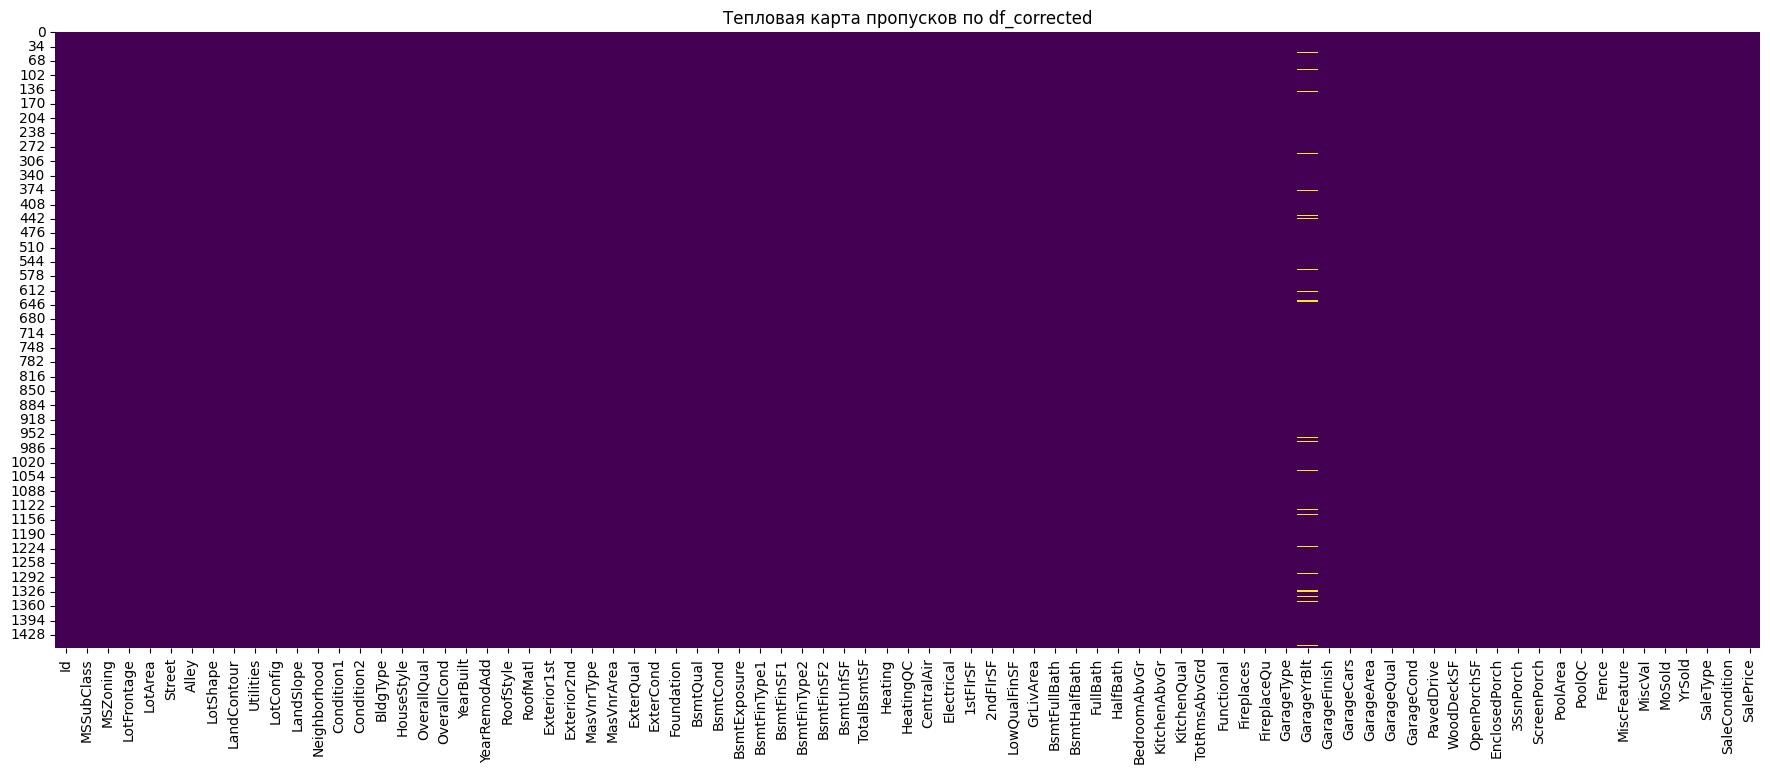

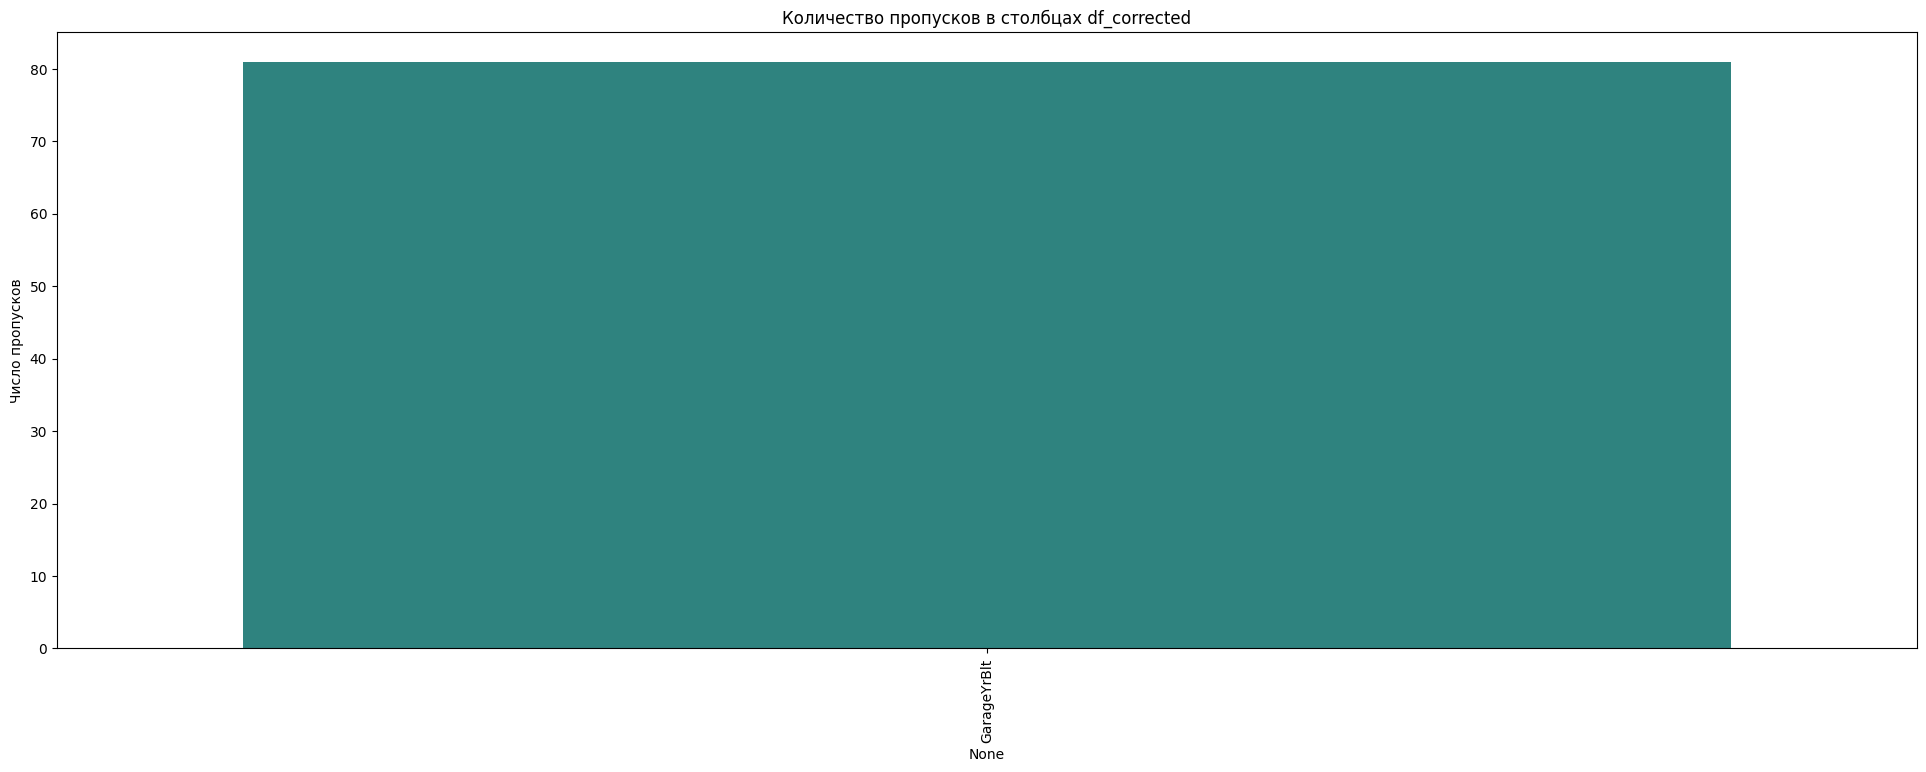

In [219]:
# Повторяем визуализацию пропущенных значений, но уже для df_corrected

# Тепловая карта пропущенных значений
plt.figure(figsize=(22,8))
sns.heatmap(df_corrected.isnull(), cbar=False, cmap="viridis")
plt.title("Тепловая карта пропусков по df_corrected")
plt.show()

# Гистограмма по количеству пропусков в каждой колонке
missing_counts = df_corrected.isnull().sum()
cols_with_missing = missing_counts[missing_counts > 0]
plt.figure(figsize=(24,8))
ax = sns.barplot(x=cols_with_missing.index, y=cols_with_missing.values, palette='viridis')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.ylabel("Число пропусков")
plt.title("Количество пропусков в столбцах df_corrected")
plt.show()



Все значения были заменены на логичные (что доказуемо визуализацией). Только значение с годом постройки ОТСУТСВУЮЩИХ гаражей оставили пустым, чтобы они не влияли на вычисления с другими годами.

## C) Расширенная статистика

Для числовых колонок выведите: min, max, mean, median, mode.

In [220]:
# Для числовых колонок выведите: min, max, mean, median, mode.

# Выделим только числовые столбцы
num_columns = df_corrected.select_dtypes(include=['number']).columns

# Создадим DataFrame с min, max, mean, median
stats = df_corrected[num_columns].agg(['min', 'max', 'mean', 'median']).T

# Добавим mode
modes = df_corrected[num_columns].mode().iloc[0]
stats['mode'] = modes

display(stats.drop(index='Id')) #+исключили id


,min,max,mean,median,mode
MSSubClass,20.0,190.0,56.897260,50.0,20.0
LotFrontage,21.0,313.0,69.553425,68.0,68.0
LotArea,1300.0,215245.0,10516.828082,9478.5,7200.0
OverallQual,1.0,10.0,6.099315,6.0,5.0
OverallCond,1.0,9.0,5.575342,5.0,5.0
YearBuilt,1872.0,2010.0,1971.267808,1973.0,2006.0
YearRemodAdd,1950.0,2010.0,1984.865753,1994.0,1950.0
MasVnrArea,0.0,1600.0,103.117123,0.0,0.0
BsmtFinSF1,0.0,5644.0,443.639726,383.5,0.0
BsmtFinSF2,0.0,1474.0,46.549315,0.0,0.0


Проверка выбросов методом 3х сигм

In [221]:
# Реализуем правило трех сигм для проверки выбросов для числовых столбцов

outliers_3sigma = {}
for col in num_columns:
    if col == 'Id':
        continue
    series = df_corrected[col].dropna()
    mean = series.mean()
    std = series.std()
    lower_bound = mean - 3 * std
    upper_bound = mean + 3 * std
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    outliers_3sigma[col] = len(outliers)

outliers_3sigma_df = pd.DataFrame.from_dict(outliers_3sigma, orient='index', columns=['num_outliers'])

# Выводим таблицу с количеством выбросов, а также отдельно: Общее количество выбросов и Процент выбросов относительно всех данных
display(outliers_3sigma_df.sort_values('num_outliers', ascending=False))

total_outliers = outliers_3sigma_df['num_outliers'].sum()
total_values = df_corrected[num_columns].count().sum()
percent_outliers = (total_outliers / total_values) * 100
print(f"Общее количество выбросов по правилу трех сигм: {total_outliers}")
print(f"Процент выбросов относительно всех данных: {percent_outliers:.2f}%")


,num_outliers
BsmtHalfBath,82
KitchenAbvGr,68
ScreenPorch,55
EnclosedPorch,51
BsmtFinSF2,50
MasVnrArea,32
MSSubClass,30
OverallCond,28
OpenPorchSF,27
3SsnPorch,23


Общее количество выбросов по правилу трех сигм: 688
Процент выбросов относительно всех данных: 1.24%


Посчитайте percentile/quantile (5, 25, 50, 75, 95 перцентили).

In [222]:

percentiles = [5, 25, 50, 75, 95]
percentiles_df = df_corrected[num_columns].quantile([p/100 for p in percentiles]).T
percentiles_df.columns = [f"{int(p)}th" for p in percentiles]
# Перцентили (percentiles) — это значения, которые делят данные на сто равных частей. 
# Например, 5-й перцентиль — это такое значение, ниже которого находится 5% наблюдений, 
# 50-й перцентиль — это медиана (середина распределения), 
# а 95-й перцентиль — такая граница, ниже которой лежат 95% всех данных. 
# Перцентили используют для понимания распределения данных, анализа выбросов и 
# сравнения величин в разных частях распределения.
display(percentiles_df.drop(index='Id'))

,5th,25th,50th,75th,95th
MSSubClass,20.00,20.00,50.0,70.00,160.00
LotFrontage,35.95,60.00,68.0,80.00,104.00
LotArea,3311.70,7553.50,9478.5,11601.50,17401.15
OverallQual,4.00,5.00,6.0,7.00,8.00
OverallCond,4.00,5.00,5.0,6.00,8.00
YearBuilt,1916.00,1954.00,1973.0,2000.00,2007.00
YearRemodAdd,1950.00,1967.00,1994.0,2004.00,2007.00
MasVnrArea,0.00,0.00,0.0,164.25,456.00
BsmtFinSF1,0.00,0.00,383.5,712.25,1274.00
BsmtFinSF2,0.00,0.00,0.0,0.00,396.20


Самостоятельно изучите и посчитайте: дисперсию (variance), асимметрию (skewness) и эксцесс (kurtosis). Попробуйте объяснить, что они значат для ваших данных.

In [223]:
# Расчет стандартного отклонения, дисперсии, асимметрии и эксцесса для числовых признаков
std = df_corrected[num_columns].std()
variance = df_corrected[num_columns].var()
skewness = df_corrected[num_columns].skew()
kurtosis = df_corrected[num_columns].kurtosis()

# Дисперсия (variance) — показывает, насколько сильно значения признака отклоняются от среднего. 
# Чем выше дисперсия, тем больше разброс данных. Например, если у признака высокая дисперсия, его значения могут сильно отличаться от среднего.
# Асимметрия (skewness) — измеряет симметричность распределения данных относительно среднего. 
# Если асимметрия положительная, хвост распределения вытянут вправо (большие значения встречаются реже), если отрицательная — влево.
# Эксцесс (kurtosis) — показывает, насколько "тяжелыми" являются хвосты распределения по сравнению с нормальным распределением.
# Высокий эксцесс говорит о большем количестве выбросов, низкий — о более "плоском" распределении.

stats_df = pd.DataFrame({
    "standart deviation": std,
    "variance": variance,
    "skewness": skewness,
    "kurtosis": kurtosis
})

display(stats_df.drop(index='Id'))

,standart deviation,variance,skewness,kurtosis
MSSubClass,42.300571,1.789338e+03,1.407657,1.580188
LotFrontage,22.433373,5.032562e+02,2.302708,20.307816
LotArea,9981.264932,9.962565e+07,12.207688,203.243271
OverallQual,1.382997,1.912679e+00,0.216944,0.096293
OverallCond,1.112799,1.238322e+00,0.693067,1.106413
YearBuilt,30.202904,9.122154e+02,-0.613461,-0.439552
YearRemodAdd,20.645407,4.262328e+02,-0.503562,-1.272245
MasVnrArea,180.731373,3.266383e+04,2.677616,10.141416
BsmtFinSF1,456.098091,2.080255e+05,1.685503,11.118236
BsmtFinSF2,161.319273,2.602391e+04,4.255261,20.113338


In [224]:
# Из таблицы выше выберем по 4 признака с наибольшими значениями для каждого параметра

stats_df_nid = stats_df.drop(index='Id', errors='ignore')

top_variance = stats_df_nid["variance"].sort_values(ascending=False).head(4)
top_skewness = stats_df_nid["skewness"].abs().sort_values(ascending=False).head(4)  # по модулю, ищем наибольшую асимметрию
top_kurtosis = stats_df_nid["kurtosis"].abs().sort_values(ascending=False).head(4)  # по модулю, ищем наибольший эксцесс

print("4 признака с самой большой дисперсией:\n", top_variance, "\n")
print("4 признака с самой большой асимметрией (по модулю):\n", top_skewness, "\n")
print("4 признака с самым большим эксцессом (по модулю):\n", top_kurtosis, "\n")

4 признака с самой большой дисперсией:
 SalePrice    6.311111e+09
LotArea      9.962565e+07
GrLivArea    2.761296e+05
MiscVal      2.461381e+05
Name: variance, dtype: float64 

4 признака с самой большой асимметрией (по модулю):
 MiscVal      24.476794
PoolArea     14.828374
LotArea      12.207688
3SsnPorch    10.304342
Name: skewness, dtype: float64 

4 признака с самым большим эксцессом (по модулю):
 MiscVal      701.003342
PoolArea     223.268499
LotArea      203.243271
3SsnPorch    123.662379
Name: kurtosis, dtype: float64 



На основании рассчитанных характеристик можно сделать следующие выводы о данных:
- По значениям стандартного отклонения и дисперсии видно, что некоторые признаки (например, LotArea, SalePrice, GarageArea) обладают большим разбросом — значения варьируются в широких пределах. Это говорит о наличии очень отличающихся объектов среди домов.
- Многие числовые признаки, такие как стоимость (SalePrice), площадь участка (LotArea), имеют положительную асимметрию (skewness), то есть основная масса домов имеет значения ниже среднего, а «дорогие» и «крупные» дома встречаются реже (длинный правый хвост).
- Высокие значения эксцесса (kurtosis) у LotArea, PoolArea, MiscVal и других признаков показывают, что среди данных много выбросов и распределения "тяжеловатохвостые" по сравнению с нормальным распределением.
- Для качественных признаков стандартное отклонение, асимметрия и эксцесс не рассчитываются, поэтому здесь рассмотрены только числовые столбцы.

В целом, для большинства признаков в датасете характерно наличие выбросов, скошенность распределения и большой разброс значений. Это важно учитывать при анализе, визуализации и построении моделей.

# D) Фичи: Энкодинг и Инжиниринг (Feature Engineering)

Label Encoding + One Hot Encoding

In [225]:
# Кодирование категориальных признаков:
# 1. Все "качественные" столбцы (с уровнями качества) закодировать label encoding с маппингом: Ex=5, Gd=4, TA=3, Fa=2, Po=1, пропуски=0.
# 2. Все остальные категориальные -- через One Hot Encoding.

# Определим категориальные признаки (тип object)
cat_columns = df_corrected.select_dtypes(include=['object']).columns

# Список качественных признаков -- по описанию и явным названиям
quality_mapping = {
    'Ex': 5,
    'Gd': 4,
    'TA': 3,
    'Fa': 2,
    'Po': 1,
}

quality_cols = [col for col in cat_columns if (
    'Qual' in col or
    'Cond' in col or
    'QC'   in col or
    col in ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 
            'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']
)]

# Применяем маппинг к "качественным" колонкам
df_encoded = df_corrected.copy()
for col in quality_cols:
    df_encoded[col] = df_encoded[col].map(quality_mapping)
    df_encoded[col] = df_encoded[col].fillna(0).astype(int)

# Категориальные признаки, не являющиеся качественными
other_cat_columns = [col for col in cat_columns if col not in quality_cols]

# Применяем One Hot Encoding к остальным категориальным колонкам
df_encoded = pd.get_dummies(df_encoded, columns=other_cat_columns, drop_first=False)

# Повторно применим One Hot Encoding К ТОЛЬКО Condition1 и Condition2
df_encoded = pd.get_dummies(df_encoded, columns=['Condition1', 'Condition2'], drop_first=False)
display(df_encoded.head(10))
print(df_encoded.shape)

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,HeatingQC,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Fireplaces,FireplaceQu,GarageYrBlt,GarageCars,GarageArea,GarageQual,GarageCond,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,MiscVal,MoSold,YrSold,SaleCondition,SalePrice,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Grvl,Street_Pave,Alley_Grvl,Alley_NoAlley,Alley_Pave,LotShape_IR1,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_Bnk,LandContour_HLS,LandContour_Low,LandContour_Lvl,Utilities_AllPub,Utilities_NoSeWa,LotConfig_Corner,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,LandSlope_Gtl,LandSlope_Mod,LandSlope_Sev,Neighborhood_Blmngtn,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,BldgType_1Fam,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Fin,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Flat,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Shed,RoofMatl_ClyTile,RoofMatl_CompShg,RoofMatl_Membran,RoofMatl_Metal,RoofMatl_Roll,RoofMatl_Tar&Grv,RoofMatl_WdShake,RoofMatl_WdShngl,Exterior1st_AsbShng,Exterior1st_AsphShn,Exterior1st_BrkComm,Exterior1st_BrkFace,Exterior1st_CBlock,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_AsbShng,Exterior2nd_AsphShn,Exterior2nd_Brk Cmn,Exterior2nd_BrkFace,Exterior2nd_CBlock,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_Other,Exterior2nd_Plywood,Exterior2nd_Stone,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,MasVnrType_BrkCmn,MasVnrType_BrkFace,MasVnrType_NoVrn,MasVnrType_Stone,Foundation_BrkTil,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,BsmtExposure_Av,BsmtExposure_Gd,BsmtExposure_Mn,BsmtExposure_No,BsmtExposure_NoBasement,BsmtFinType1_ALQ,BsmtFinType1_BLQ,BsmtFinType1_GLQ,BsmtFinType1_LwQ,BsmtFinType1_NoBasement,BsmtFinType1_Rec,BsmtFinType1_Unf,BsmtFinType2_ALQ,BsmtFinType2_BLQ,BsmtFinType2_GLQ,BsmtFinType2_LwQ,BsmtFinType2_NoBasement,BsmtFinType2_Rec,BsmtFinType2_Unf,Heating_Floor,Heating_GasA,Heating_GasW,Heating_Grav,Heating_OthW,Heating_Wall,CentralAir_N,CentralAir_Y,Electrical_FuseA,Electrical_FuseF,Electrical_FuseP,Electrical_Mix,Electrical_SBrkr,Functional_Maj1,Functional_Maj2,Functional_Min1,Functional_Min2,Functional_Mod,Functional_Sev,Functional_Typ,GarageType_2Types,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageType_NoGarage,GarageFinish_Fin,GarageFinish_NoGarage,GarageFinish_RFn,GarageFinish_Unf,PavedDrive_N,PavedDrive_P,PavedDrive_Y,Fence_GdPrv,Fence_GdWo,Fence_MnPrv,Fence_MnWw,Fence_NoFence,MiscFeature_Gar2,MiscFeature_NoFeature,MiscFeature_Othr,MiscFeature_Shed,MiscFeature_TenC,SaleType_COD,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,Condition1_0,Condition2_0
0,1,60,65.0,8450,7,5,2003,2003,196.0,4,3,4,3,706,0,150,856,5,856,854,0,1710,1,0,2,1,3,1,4,8,0,0,2003.0,2,548,3,3,0,61,0,0,0,0,0,0,2,2008,0,208500,False,False,F

(1460, 244)


Feature Engineering. Объединим YearBuilt, YearRemodAdd, GarageYrBlt (c разными весами), так как эти параметры во многом связаны между собой.

In [226]:
# Создадим новую колонку Year как взвешенное среднее из YearBuilt, YearRemodAdd, GarageYrBlt
# Вес YearBuilt = 0.7, YearRemodAdd = 0.2, GarageYrBlt = 0.1
df_encoded['Year'] = (
    df_encoded['YearBuilt'] * 0.7 +
    df_encoded['YearRemodAdd'] * 0.2 +
    df_encoded['GarageYrBlt'].fillna(df_encoded['GarageYrBlt'].median()) * 0.1
)
# Округлим Year к целому
df_encoded['Year'] = df_encoded['Year'].round().astype(int)
df_encoded = df_encoded.drop(['YearBuilt', 'YearRemodAdd', 'GarageYrBlt'], axis=1)

In [227]:
# Для нового столбца 'Year' посчитаем те же метрики, что и ранее для числовых столбцов
year_metrics = pd.Series({
    'min': df_encoded['Year'].min(),
    'max': df_encoded['Year'].max(),
    'mean': df_encoded['Year'].mean(),
    'median': df_encoded['Year'].median(),
    'mode': df_encoded['Year'].mode()[0],
    'std': df_encoded['Year'].std(),
    'var': df_encoded['Year'].var(),
    'skewness': df_encoded['Year'].skew(),
    'kurtosis': df_encoded['Year'].kurtosis(),
    '5th': df_encoded['Year'].quantile(0.05),
    '25th': df_encoded['Year'].quantile(0.25),
    '50th': df_encoded['Year'].quantile(0.5),
    '75th': df_encoded['Year'].quantile(0.75),
    '95th': df_encoded['Year'].quantile(0.95),
})
print("Метрики для нового признака 'Year':")
display(year_metrics)

Метрики для нового признака 'Year':


min         1899.000000
max         2010.000000
mean        1974.687671
median      1975.000000
mode        2006.000000
std           25.738437
var          662.467154
skewness      -0.380576
kurtosis      -0.889956
5th         1930.000000
25th        1957.000000
50th        1975.000000
75th        2000.250000
95th        2007.000000
dtype: float64

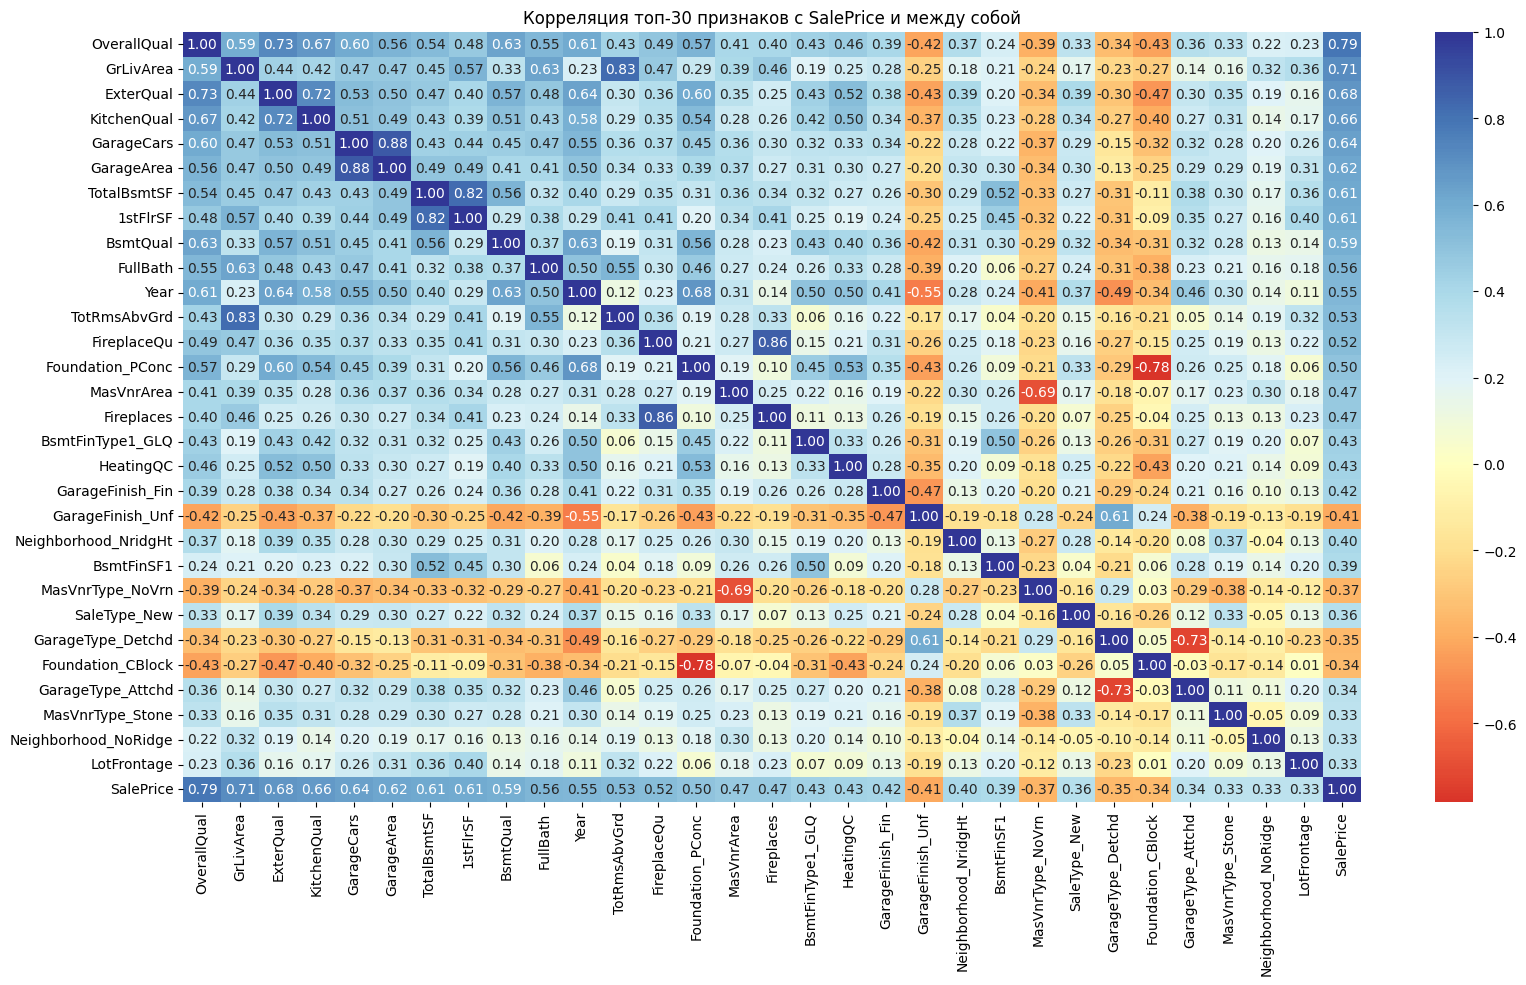

Оставлено признаков: 37
Удалённые признаки:
['3SsnPorch', 'Alley_Grvl', 'Alley_NoAlley', 'Alley_Pave', 'BedroomAbvGr', 'BldgType_1Fam', 'BldgType_2fmCon', 'BldgType_Duplex', 'BldgType_Twnhs', 'BldgType_TwnhsE', 'BsmtCond', 'BsmtExposure_Av', 'BsmtExposure_Mn', 'BsmtExposure_No', 'BsmtExposure_NoBasement', 'BsmtFinSF2', 'BsmtFinType1_ALQ', 'BsmtFinType1_BLQ', 'BsmtFinType1_LwQ', 'BsmtFinType1_NoBasement', 'BsmtFinType1_Rec', 'BsmtFinType1_Unf', 'BsmtFinType2_ALQ', 'BsmtFinType2_BLQ', 'BsmtFinType2_GLQ', 'BsmtFinType2_LwQ', 'BsmtFinType2_NoBasement', 'BsmtFinType2_Rec', 'BsmtFinType2_Unf', 'BsmtFullBath', 'BsmtHalfBath', 'BsmtUnfSF', 'CentralAir_N', 'CentralAir_Y', 'Condition1_0', 'Condition2_0', 'Electrical_FuseA', 'Electrical_FuseF', 'Electrical_FuseP', 'Electrical_Mix', 'Electrical_SBrkr', 'EnclosedPorch', 'ExterCond', 'Exterior1st_AsbShng', 'Exterior1st_AsphShn', 'Exterior1st_BrkComm', 'Exterior1st_BrkFace', 'Exterior1st_CBlock', 'Exterior1st_CemntBd', 'Exterior1st_HdBoard', 'Exterio

In [228]:
# Посчитаем матрицу корреляций для числовых столбцов
corr_matrix = df_encoded.corr(numeric_only=True)


# Топ-20 признаков по абсолютной корреляции с SalePrice (кроме самой SalePrice)
top_corr = corr_matrix['SalePrice'].abs().sort_values(ascending=False).iloc[1:31]
top_features = top_corr.index

plt.figure(figsize=(19,10))
sns.heatmap(df_encoded[top_features.tolist() + ['SalePrice']].corr(), annot=True, fmt=".2f", cmap="RdYlBu", center=0)
plt.title("Корреляция топ-30 признаков с SalePrice и между собой")
plt.show()

# Оставим только те признаки, у которых абсолютное значение корреляции с SalePrice >= 0.1
corr_with_saleprice = corr_matrix['SalePrice'].abs()
cols_to_keep = corr_with_saleprice[corr_with_saleprice >= 0.3].index
df_encoded_filtered = df_encoded[cols_to_keep]
print(f"Оставлено признаков: {df_encoded_filtered.shape[1]}")
# Определим удалённые признаки
removed_cols = set(df_encoded.columns) - set(df_encoded_filtered.columns)
print("Удалённые признаки:")
print(sorted(removed_cols))




Район - очень важный признак. Поэтому:
В следующей клетке кода мы определяем новые признаки, связанные с районом (Neighborhood), которые были удалены после отбора по корреляции, и группируем их в один бинарный признак 'Neighborhood_Other'. Затем вычисляем корреляцию этого нового признака с целевой переменной SalePrice, чтобы оценить его информативность.

In [229]:
# Определяем все оставшиеся признаки Neighborhood в df_encoded_filtered
remaining_neigh_cols = [col for col in df_encoded.columns if col.startswith('Neighborhood_') and col in removed_cols]
# Cоздаём столбец Neighborhood_Other:
df_encoded_filtered['Neighborhood_Other'] = df_encoded[remaining_neigh_cols].any(axis=1)
# Посчитаем корреляцию нового признака с SalePrice
corr_other = df_encoded_filtered['Neighborhood_Other'].corr(df_encoded_filtered['SalePrice'])
print("Корреляция добавленного признака Neighborhood_Other с SalePrice:", corr_other)

Корреляция добавленного признака Neighborhood_Other с SalePrice: -0.530060802270081


Отсортируем и выведем df_encoded_filtered, создадим df_encoded_filtered_sorted который для простоты переименуем в итоговый датасет df_ready

In [230]:
# Получаем абсолютные значения корреляции с SalePrice (кроме самого SalePrice)
corr_values = df_encoded_filtered.corr(numeric_only=True)['SalePrice'].abs().sort_values(ascending=False)
# Отсортируем столбцы по этим значениям
sorted_cols = corr_values.index.tolist()
df_encoded_filtered_sorted = df_encoded_filtered[sorted_cols]

display(df_encoded_filtered_sorted.head(10))
print(df_encoded_filtered_sorted.shape)

,SalePrice,OverallQual,GrLivArea,ExterQual,KitchenQual,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,BsmtQual,FullBath,Year,TotRmsAbvGrd,Neighborhood_Other,FireplaceQu,Foundation_PConc,MasVnrArea,Fireplaces,BsmtFinType1_GLQ,HeatingQC,GarageFinish_Fin,GarageFinish_Unf,Neighborhood_NridgHt,BsmtFinSF1,MasVnrType_NoVrn,SaleType_New,GarageType_Detchd,Foundation_CBlock,GarageType_Attchd,MasVnrType_Stone,Neighborhood_NoRidge,LotFrontage,WoodDeckSF,2ndFlrSF,OpenPorchSF,BsmtExposure_Gd,Exterior2nd_VinylSd,Exterior1st_VinylSd
0,208500,7,1710,4,4,2,548,856,856,4,2,2003,8,True,0,True,196.0,0,True,5,False,False,False,706,False,False,False,False,True,False,False,65.0,0,854,61,False,True,True
1,181500,6,1262,3,3,2,460,1262,1262,4,2,1976,6,True,3,False,0.0,1,False,5,False,False,False,978,True,False,False,True,True,False,False,80.0,298,0,0,True,False,False
2,223500,7,1786,4,4,2,608,920,920,4,2,2001,6,True,3,True,162.0,1,True,5,False,False,False,486,False,False,False,False,True,False,False,68.0,0,866,42,False,True,True
3,140000,7,1717,3,4,3,642,756,961,3,1,1934,7,True,4,False,0.0,1,False,4,False,True,False,216,True,False,True,False,False,False,False,60.0,0,756,35,False,False,False
4,250000,8,2198,4,4,3,836,1145,1145,4,2,2000,9,False,3,True,350.0,1,True,5,False,False,False,655,False,False,False,False,True,False,True,84.0,192,1053,84,False,True,True
5,143000,5,1362,3,3,2,480,796,796,4,1,1993,5,True,0,False,0.0,0,True,5,False,True,False,732,True,False,False,False,True,False,False,85.0,40,566,30,False,True,True
6,307000,8,1694,4,4,2,636,1686,1694,5,2,2004,7,True,4,True,186.0,1,True,5,False,False,False,1369,False,False,False,False,True,True,False,75.0,255,0,57,False,True,True
7,200000,7,2090,3,3,2,484,1107,1107,4,2,1973,7,True,3,False,240.0,2,False,5,False,False,False,859,False,False,False,True,True,True,False,80.0,235,983,204,False,False,False
8,129900,7,1774,3,3,2,468,952,1022,3,2,1935,8,True,3,False,0.0,2,False,4,False,True,False,0,True,False,True,False,False,False,False,51.0,90,752,0,False,False,False
9,118000,5,1077,3,3,1,205,991,1077,3,1,1941,5,True,3,False,0.0,2,True,5,False,False,False,851,True,False,False,False,True,False,False,50.0,0,0,4,False,False,False


(1460, 38)


_Примечание: LotArea — не жилплощадь. Она не имеет такого значения, как остальные показатели, характеризующие площади отдельных элементов. Жилая площадь — это GrLivArea._

In [231]:
df_ready = df_encoded_filtered_sorted

# E) Визуализация 

Распределение: гистограммы.

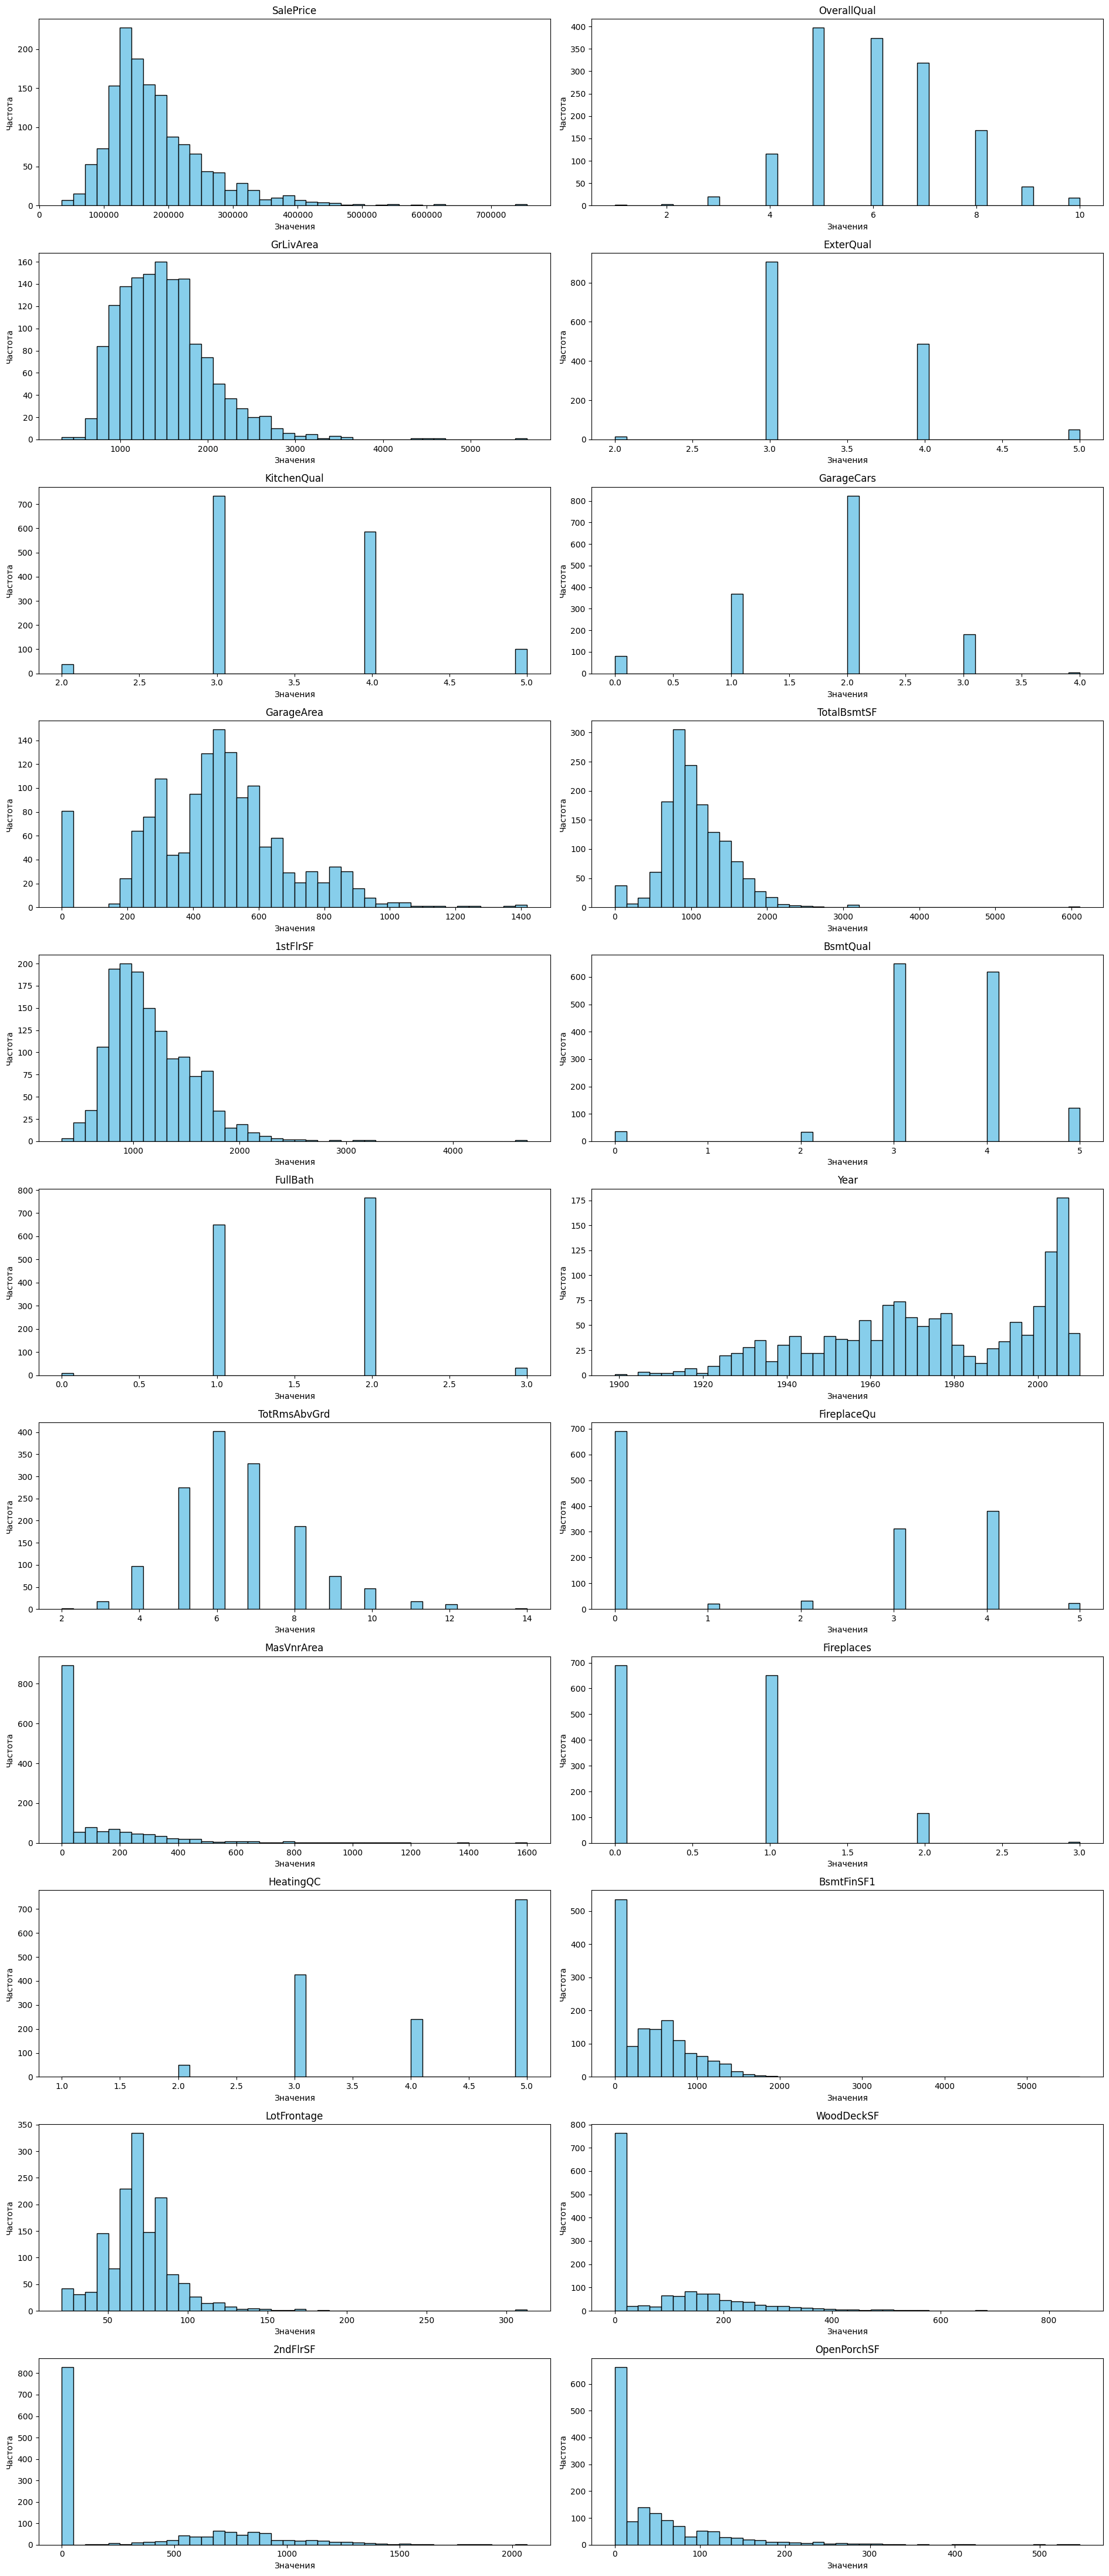

In [232]:
# Нарисуем распределения признаков, оставшихся после фильтрации по корреляции
num_cols = df_ready.select_dtypes(include=['int64', 'float64']).columns
n_cols = 2
n_rows = (len(num_cols) + 1) // n_cols

plt.figure(figsize=(19, n_rows * 4))
for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    plt.hist(df_ready[col].dropna(), bins=40, color='skyblue', edgecolor='k')
    plt.title(col)
    plt.xlabel('Значения')
    plt.ylabel('Частота')
plt.tight_layout()



Зависимости и поиск выбросов: интерактивные scatter plots для 10 самых коррелирующих признаков с SalePrice. (**Plotly**)

In [233]:
top_corr_cols = corr_with_saleprice.abs().sort_values(ascending=False).iloc[1:11].index  # исключаем сам SalePrice

for col in top_corr_cols:
    fig = px.scatter(df_ready, x=col, y='SalePrice',
                     title=f'Scatter plot: {col} vs SalePrice',
                     labels={col: col, 'SalePrice': 'SalePrice'},
                     opacity=0.6, color_discrete_sequence=['#1f77b4'])
    fig.show()

Замечаем, что аж на трех графиках есть один выброс: цена довольно низкая, но площади огромные. Проанализируем его.

In [234]:
#найдем эту точку
display(df_ready[(df_ready['SalePrice'] == 160000) & (df_ready['TotalBsmtSF'] == 6110)])
#посмотрим максимумы по интересующим нас параметрам
display(df_ready[['SalePrice', 'TotalBsmtSF']].max())

,SalePrice,OverallQual,GrLivArea,ExterQual,KitchenQual,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,BsmtQual,FullBath,Year,TotRmsAbvGrd,Neighborhood_Other,FireplaceQu,Foundation_PConc,MasVnrArea,Fireplaces,BsmtFinType1_GLQ,HeatingQC,GarageFinish_Fin,GarageFinish_Unf,Neighborhood_NridgHt,BsmtFinSF1,MasVnrType_NoVrn,SaleType_New,GarageType_Detchd,Foundation_CBlock,GarageType_Attchd,MasVnrType_Stone,Neighborhood_NoRidge,LotFrontage,WoodDeckSF,2ndFlrSF,OpenPorchSF,BsmtExposure_Gd,Exterior2nd_VinylSd,Exterior1st_VinylSd
1298,160000,10,5642,5,5,2,1418,6110,4692,5,2,2008,12,True,4,True,796.0,3,True,5,True,False,False,5644,False,True,False,False,True,True,False,313.0,214,950,292,True,False,False


SalePrice      755000
TotalBsmtSF      6110
dtype: int64

Видно, что это реальный особняк, т.е не ошибка,и он причем соответствует максимуму показателя по всем данным. Тем не менее, удивительно, что цена в примерно в 5 раз меньше максимума. Разберемся.

In [235]:
# дополнительно возьмем эту строчку прямо из первого датасета df и извлечем столбец SaleCondition, чтобы понять специфичность сделки
display(df[(df['SalePrice'] == 160000) & (df['TotalBsmtSF'] == 6110)]['SaleCondition'])

1298    Partial
Name: SaleCondition, dtype: str

SaleCondition = **Partial**, значит сделка - непростая. 
Скорее всего, продается не готовый дом, а либо:

- Объект на этапе строительства (продажа с дисконтом под завершение)
- Частичная продажа долей/этапов строительства
- Сделка, где цена отражает только часть работ

TotalBsmtSF такой большой потому, что туда скорее всего вошла площадь фундамента/котлована/недостроенная площадь дома вообще.

Для построенияы модели эти данные не подходят, так как в датасете df_ready особые сделки не учитываются. Удалим эту запись.

In [236]:
df_ready = df_ready[~((df_ready['SalePrice'] == 160000) & (df_ready['TotalBsmtSF'] == 6110))]

PS. до этого уже рисовал разнообразные графики, в т.ч. bar plots и correlation heatmaps.

# F) Итоговые выводы

### Что я понял про датасет (7–12 тезисов):
- Данные — по жилым домам, много признаков: площадь, материалы, категория района, качество и т.д.
- Целевая переменная: SalePrice (рыночная стоимость дома).
- Пропуски есть, но в основном в категориальных полях типа Alley/Fence; большинство из них — реальное отсутствие, а не ошбика ('NoAlley' и др.).
- Распределения многих количественных признаков сильно скошены (LotArea, SalePrice и др.)
- Есть аномалии и выбросы, например, очень большие площади при низкой цене (недостроенные объекты).
- Явные связи между качеством дома и ценой: OverallQual, ExterQual и др. визуально сильно коррелируют с SalePrice.
- Некоторые категориальные признаки требуют острожной обработки — например, Neighborhood.
- Доминируют определённые значения: по электричеству почти все SBrkr, по CentralAir — почти все Y.
- Много переменных, описывающих гаражи и подвал — их вклад в стоимость может быть существенным.
- Категориальные признаки часто имеют стандартную шкалу 'Ex', 'Gd', 'TA', 'Fa', 'Po'.
- Временные признаки (год постройки/ремонта) дают тренд: более новые дома дороже.
- Сезон продажи (месяц/год) может влиять на целевую переменную.

### Гипотезы/наблюдения (3–5):
- Качество и расположение (OverallQual, Neighborhood) — сильнейшие предикторы SalePrice.
- Выбросы обычно связаны с необычными типами сделки или незавершённостью объекта (например, SaleCondition='Partial').
- Материал внешней отделки и типы фундамента могут давать разницу в цене, но влияние неоднородно внутри класса.
- Признаки, связанные с площадями дополнительных помещений (гараж, подвал), значимы только при хорошей отделке/качестве.
- Некоторые категориальные переменные редко встречаются — их стоит агрегировать или объединять.

### Что делал бы дальше:
- Дальше взял бы линейную регрессию, чтобы предсказыват рыночную цену.
- ИИ РЕКОМЕНДУЕТ: Предсказывал бы SalePrice в логарифмическом масштабе — распределение сильно скошено.
- Сделал бы акцент на обработку выбросов и создание новых признаков (feature engineering), особенно по категориям качества, районам, времени.

### Какие подсказки брал у AI и что проверял/дописывал руками:
- Просил помощь в написании сложных фрагментов кода, а также просил объяснить некоторую теорию
- Использовал AI для сверки интерпретации категориальных значений и стратегий обработки пропусков.
- Спросил, как лучше кодировать редкие категории — попробовал target encoding vs. one-hot сам.
- Запрашивал рецепты по отлову outliers.
- Пользовался советами по визуализации (heatmap, barplot), итоговый выбор параметров и видов графиков делал вручную.
- Просил помочь с выводами к полученным показателям